# Common Graph Construction Layer

**Roadmap step 6** — build a reusable session-to-graph converter that all model variants (SR-GNN, TAGNN, GAT-SR-GNN, GAT-TAGNN, GAT-SAGPool) share.

Each session prefix is converted into a **directed weighted graph** following the SR-GNN / TAGNN construction:

- **Nodes** = unique items in the prefix (one node per distinct item).
- **Directed edges** = consecutive click transitions `item[i] → item[i+1]`.
- **Edge weights** = transition count normalized by the source node's out-degree.
- Repeated items within a session are supported: they map to the same node but may create multiple or heavier edges.

The output is a **PyTorch Geometric `Data` object** per prefix-target example, ready for batching with `Batch.from_data_list()` and consumption by any PyG message-passing layer.

In [1]:
from __future__ import annotations

import gzip
import pickle
from collections import Counter
from pathlib import Path
from typing import Iterator

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

PROJECT_ROOT = Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

YOOCHOOSE_PATH = PROCESSED_DIR / "yoochoose_1_64_preprocessed.pkl.gz"
DIGINETICA_PATH = PROCESSED_DIR / "diginetica_preprocessed.pkl.gz"

print(f"Yoochoose processed exists: {YOOCHOOSE_PATH.exists()}")
print(f"Diginetica processed exists: {DIGINETICA_PATH.exists()}")

/Users/karol/university/semester/6/glebokie-i-grafowe-sieci-neuronowe/cwp/Session-based-Recommendation-with-Graph-Attention-Networks/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Yoochoose processed exists: True
Diginetica processed exists: True


## Load preprocessed data

Re-use the serialized payload from `dataset_preprocessing.ipynb`. Each payload contains `train` and `test` dicts with keys `session_ids`, `session_dates`, `session_item_sequences`.

In [2]:
Session = tuple[int, pd.Timestamp, list[int]]


def load_payload(path: Path) -> dict:
    with gzip.open(path, "rb") as f:
        return pickle.load(f)


def payload_to_sessions(split: dict) -> list[Session]:
    """Reconstruct Session tuples from the serialized split dict."""
    return [
        (sid, pd.Timestamp(date), items)
        for sid, date, items in zip(
            split["session_ids"],
            split["session_dates"],
            split["session_item_sequences"],
        )
    ]


def iter_prefix_examples(
    sessions: list[Session],
) -> Iterator[tuple[list[int], int]]:
    """Yield (prefix, target) pairs lazily — identical to preprocessing notebook."""
    for _, _, items in sessions:
        for end_idx in range(1, len(items)):
            yield items[:end_idx], items[end_idx]


yoochoose_payload = load_payload(YOOCHOOSE_PATH)
diginetica_payload = load_payload(DIGINETICA_PATH)

yc_train = payload_to_sessions(yoochoose_payload["train"])
yc_test = payload_to_sessions(yoochoose_payload["test"])
dg_train = payload_to_sessions(diginetica_payload["train"])
dg_test = payload_to_sessions(diginetica_payload["test"])

print(f"Yoochoose train sessions: {len(yc_train):,}")
print(f"Yoochoose test  sessions: {len(yc_test):,}")
print(f"Diginetica train sessions: {len(dg_train):,}")
print(f"Diginetica test  sessions: {len(dg_test):,}")

Yoochoose train sessions: 124,471
Yoochoose test  sessions: 512
Diginetica train sessions: 186,670
Diginetica test  sessions: 15,963


## `build_session_graph` — core converter

Algorithm for prefix `[v1, v2, v3, v2, v4]` with target `v5`:

| Step | Result |
|------|--------|
| Unique items (first-appearance order) | `{v1:0, v2:1, v3:2, v4:3}` |
| Directed transitions | `(0→1), (1→2), (2→1), (1→3)` |
| Raw edge counts | `{(0,1):1, (1,2):1, (2,1):1, (1,3):1}` |
| Out-degree normalization | node 1 has out-degree 2 → edges from 1 get weight 0.5 |
| `sequence` | `[0, 1, 2, 1, 3]` |

In [3]:
def build_session_graph(prefix: list[int], target: int) -> Data:
    """Convert a session prefix + target into a PyG Data object.

    Returns a directed graph where:
      - nodes  = unique items (order of first appearance)
      - edges  = consecutive click transitions, weighted by
                 count / out-degree of source (SR-GNN style)
    """
    # --- node mapping (preserve first-appearance order) ---
    item_to_local: dict[int, int] = {}
    for item in prefix:
        if item not in item_to_local:
            item_to_local[item] = len(item_to_local)

    num_nodes = len(item_to_local)
    node_ids = list(item_to_local.keys())

    # --- sequence in local indices ---
    sequence = [item_to_local[item] for item in prefix]

    # --- directed edges with counts ---
    edge_counts: Counter[tuple[int, int]] = Counter()
    for i in range(len(sequence) - 1):
        edge_counts[(sequence[i], sequence[i + 1])] += 1

    # --- out-degree per source node ---
    out_degree: Counter[int] = Counter()
    for (src, _), cnt in edge_counts.items():
        out_degree[src] += cnt

    # --- build COO + normalized weights ---
    sources, targets, weights = [], [], []
    for (src, tgt), cnt in edge_counts.items():
        sources.append(src)
        targets.append(tgt)
        weights.append(cnt / out_degree[src])

    edge_index = torch.tensor([sources, targets], dtype=torch.long)
    edge_weight = torch.tensor(weights, dtype=torch.float)

    if len(sources) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_weight = torch.zeros(0, dtype=torch.float)

    return Data(
        x=torch.tensor(node_ids, dtype=torch.long),
        edge_index=edge_index,
        edge_weight=edge_weight,
        sequence=torch.tensor(sequence, dtype=torch.long),
        y=torch.tensor(target, dtype=torch.long),
        num_nodes=num_nodes,
    )

In [4]:
# Quick manual sanity check
g = build_session_graph([10, 20, 30, 20, 40], target=50)
print("x (global IDs):", g.x.tolist())
print("edge_index:\n", g.edge_index.tolist())
print("edge_weight:", g.edge_weight.tolist())
print("sequence:", g.sequence.tolist())
print("y:", g.y.item())
print("num_nodes:", g.num_nodes)

assert g.x.tolist() == [10, 20, 30, 40], "node IDs wrong"
assert g.num_nodes == 4
assert g.sequence.tolist() == [0, 1, 2, 1, 3]
assert g.y.item() == 50

expected_edges = {(0, 1): 1.0, (1, 2): 0.5, (2, 1): 1.0, (1, 3): 0.5}
for i in range(g.edge_index.size(1)):
    src, tgt = g.edge_index[0, i].item(), g.edge_index[1, i].item()
    w = g.edge_weight[i].item()
    assert abs(w - expected_edges[(src, tgt)]) < 1e-6, f"weight wrong for ({src},{tgt})"

print("\nAll assertions passed.")

x (global IDs): [10, 20, 30, 40]
edge_index:
 [[0, 1, 2, 1], [1, 2, 1, 3]]
edge_weight: [1.0, 0.5, 1.0, 0.5]
sequence: [0, 1, 2, 1, 3]
y: 50
num_nodes: 4

All assertions passed.


## `SessionGraphDataset`

Wraps a list of sessions into a `torch.utils.data.Dataset` of PyG `Data` objects (one per prefix-target pair). Compatible with PyG's `DataLoader` via `torch_geometric.loader.DataLoader`.

In [5]:
from torch.utils.data import Dataset as TorchDataset
from torch_geometric.loader import DataLoader as PyGDataLoader


class SessionGraphDataset(TorchDataset):
    """Flat dataset of session-prefix graphs built from preprocessed sessions.

    Materialises all prefix-target pairs up front so that random access
    (required by DataLoader with shuffle) is O(1).
    """

    def __init__(self, sessions: list[Session]) -> None:
        super().__init__()
        self.graphs: list[Data] = []
        for _, _, items in sessions:
            for end_idx in range(1, len(items)):
                prefix = items[:end_idx]
                target = items[end_idx]
                self.graphs.append(build_session_graph(prefix, target))

    def __len__(self) -> int:
        return len(self.graphs)

    def __getitem__(self, idx: int) -> Data:
        return self.graphs[idx]

In [6]:
# Quick demo: build a small dataset from the first 5 yoochoose train sessions
demo_ds = SessionGraphDataset(yc_train[:5])
print(f"Demo dataset size: {len(demo_ds)} prefix-target pairs from 5 sessions")

loader = PyGDataLoader(demo_ds, batch_size=4, shuffle=False)
batch = next(iter(loader))
print(f"\nBatch object: {batch}")
print(f"  batch.x shape:          {batch.x.shape}")
print(f"  batch.edge_index shape: {batch.edge_index.shape}")
print(f"  batch.y shape:          {batch.y.shape}")
print(f"  batch.batch (graph ids): {batch.batch.tolist()}")

Demo dataset size: 12 prefix-target pairs from 5 sessions

Batch object: DataBatch(x=[10], edge_index=[2, 6], y=[4], edge_weight=[6], sequence=[10], num_nodes=10, batch=[10], ptr=[5])
  batch.x shape:          torch.Size([10])
  batch.edge_index shape: torch.Size([2, 6])
  batch.y shape:          torch.Size([4])
  batch.batch (graph ids): [0, 1, 1, 2, 2, 2, 3, 3, 3, 3]


## Inspect sample graphs from real data

In [ ]:
examples = list(zip(range(5), iter_prefix_examples(yc_train)))
for idx, (_, (prefix, target)) in enumerate(examples[:3]):
    g = build_session_graph(prefix, target)
    print(f"--- Example {idx} ---")
    print(f"  prefix:     {prefix}")
    print(f"  target:     {target}")
    print(f"  nodes:      {g.num_nodes}  ids={g.x.tolist()}")
    print(f"  edges:      {g.edge_index.size(1)}")
    print(f"  sequence:   {g.sequence.tolist()}")
    print(
        f"  last node:  {g.sequence[-1].item()} (global id {g.x[g.sequence[-1]].item()})"
    )
    print()

--- Example 0 ---
  prefix:     [214854731]
  target:     214854332
  nodes:      1  ids=[214854731]
  edges:      0
  sequence:   [0]
  last node:  0 (global id 214854731)

--- Example 1 ---
  prefix:     [214854731, 214854332]
  target:     214714755
  nodes:      2  ids=[214854731, 214854332]
  edges:      1
  sequence:   [0, 1]
  last node:  1 (global id 214854332)

--- Example 2 ---
  prefix:     [214854731, 214854332, 214714755]
  target:     214854836
  nodes:      3  ids=[214854731, 214854332, 214714755]
  edges:      2
  sequence:   [0, 1, 2]
  last node:  2 (global id 214714755)



## Visualize session graphs

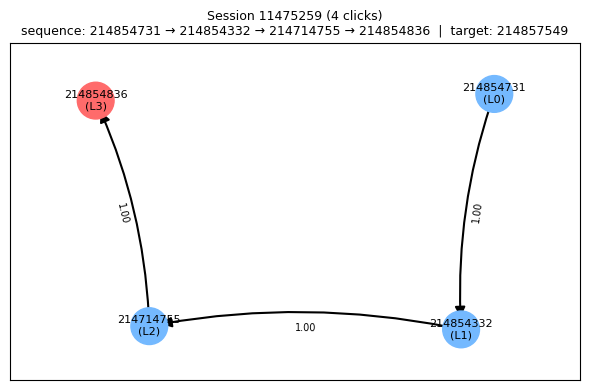

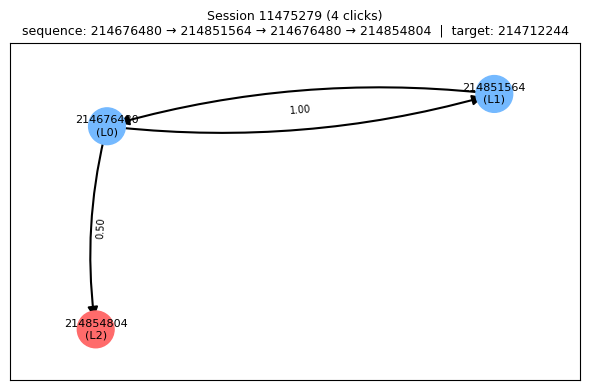

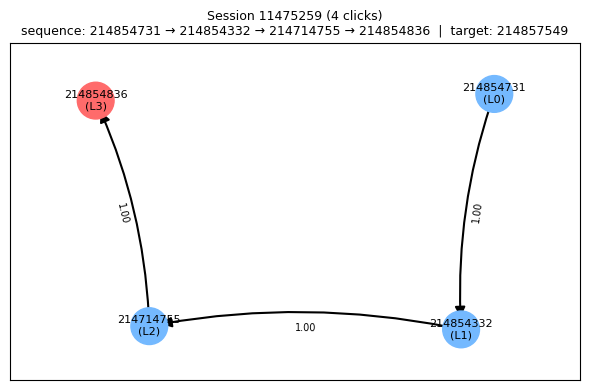

In [ ]:
def draw_session_graph(data: Data, title: str = "") -> None:
    """Draw a session graph using networkx + matplotlib."""
    G = nx.DiGraph()
    node_labels = {}
    for local_idx in range(data.num_nodes):
        global_id = data.x[local_idx].item()
        G.add_node(local_idx)
        node_labels[local_idx] = f"{global_id}\n(L{local_idx})"

    edge_labels = {}
    for i in range(data.edge_index.size(1)):
        src = data.edge_index[0, i].item()
        tgt = data.edge_index[1, i].item()
        w = data.edge_weight[i].item()
        G.add_edge(src, tgt, weight=w)
        edge_labels[(src, tgt)] = f"{w:.2f}"

    last_node = data.sequence[-1].item()
    node_colors = ["#ff6b6b" if n == last_node else "#74b9ff" for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=2.0)
    fig, ax = plt.subplots(figsize=(6, 4))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, ax=ax)
    nx.draw_networkx_edges(
        G,
        pos,
        connectionstyle="arc3,rad=0.1",
        arrowsize=15,
        width=1.5,
        ax=ax,
    )
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7,
        ax=ax,
    )
    seq_str = " → ".join(str(data.x[s].item()) for s in data.sequence.tolist())
    ax.set_title(
        f"{title}\nsequence: {seq_str}  |  target: {data.y.item()}", fontsize=9
    )
    ax.margins(0.15)
    plt.tight_layout()
    plt.show()


# Pick 3 examples with varying lengths for visual variety
vis_sessions = [s for s in yc_train if len(s[2]) >= 5][:2] + [yc_train[0]]
for i, (sid, _, items) in enumerate(vis_sessions):
    prefix, target = items[:-1], items[-1]
    g = build_session_graph(prefix, target)
    draw_session_graph(g, title=f"Session {sid} ({len(prefix)} clicks)")

## Validation checks

Run structural invariants over a sample of graphs to catch bugs early.

In [ ]:
def validate_graph(data: Data) -> None:
    """Assert structural invariants on a session graph."""
    # 1. edge_index references valid nodes
    if data.edge_index.numel() > 0:
        assert data.edge_index.min() >= 0
        assert data.edge_index.max() < data.num_nodes

    # 2. edge weights sum to ~1.0 per source node (out-degree normalization)
    if data.edge_index.numel() > 0:
        for src_node in range(data.num_nodes):
            mask = data.edge_index[0] == src_node
            if mask.any():
                weight_sum = data.edge_weight[mask].sum().item()
                assert (
                    abs(weight_sum - 1.0) < 1e-5
                ), f"node {src_node}: weight sum = {weight_sum}"

    # 3. sequence values are valid local indices
    assert data.sequence.min() >= 0
    assert data.sequence.max() < data.num_nodes

    # 4. last item in sequence matches a real node
    last_local = data.sequence[-1].item()
    assert 0 <= last_local < data.num_nodes

    # 5. no duplicate (src, tgt) pairs in edge_index
    if data.edge_index.numel() > 0:
        pairs = set()
        for i in range(data.edge_index.size(1)):
            pair = (data.edge_index[0, i].item(), data.edge_index[1, i].item())
            assert pair not in pairs, f"duplicate edge {pair}"
            pairs.add(pair)

    # 6. y is a scalar
    assert data.y.dim() == 0


# Validate over first 1000 prefix examples from each dataset
print("Validating Yoochoose graphs...")
for i, (prefix, target) in enumerate(iter_prefix_examples(yc_train)):
    if i >= 1000:
        break
    validate_graph(build_session_graph(prefix, target))
print(f"  {i + 1} graphs OK")

print("Validating Diginetica graphs...")
for i, (prefix, target) in enumerate(iter_prefix_examples(dg_train)):
    if i >= 1000:
        break
    validate_graph(build_session_graph(prefix, target))
print(f"  {i + 1} graphs OK")

print("\nAll validation checks passed.")

Validating Yoochoose graphs...
  1001 graphs OK
Validating Diginetica graphs...
  1001 graphs OK

All validation checks passed.


## Dataset-level statistics

Sample a manageable number of graphs to plot distributions of nodes, edges, and sequence lengths.

In [10]:
def collect_graph_stats(
    sessions: list[Session], max_examples: int = 50_000
) -> pd.DataFrame:
    """Build graphs from prefix examples and collect per-graph stats."""
    rows = []
    for i, (prefix, target) in enumerate(iter_prefix_examples(sessions)):
        if i >= max_examples:
            break
        g = build_session_graph(prefix, target)
        rows.append(
            {
                "num_nodes": g.num_nodes,
                "num_edges": g.edge_index.size(1),
                "seq_len": g.sequence.size(0),
            }
        )
    return pd.DataFrame(rows)


yc_stats = collect_graph_stats(yc_train, max_examples=50_000)
dg_stats = collect_graph_stats(dg_train, max_examples=50_000)

print("Yoochoose graph stats:")
print(yc_stats.describe().round(2))
print("\nDiginetica graph stats:")
print(dg_stats.describe().round(2))

Yoochoose graph stats:
       num_nodes  num_edges   seq_len
count   50000.00   50000.00  50000.00
mean        3.95       3.54      4.69
std         6.60       7.26      7.46
min         1.00       0.00      1.00
25%         1.00       0.00      1.00
50%         2.00       1.00      2.00
75%         4.00       4.00      5.00
max       122.00     125.00    128.00

Diginetica graph stats:
       num_nodes  num_edges   seq_len
count   50000.00   50000.00  50000.00
mean        3.49       2.94      4.02
std         3.20       3.73      3.83
min         1.00       0.00      1.00
25%         1.00       0.00      1.00
50%         2.00       2.00      3.00
75%         5.00       4.00      5.00
max        49.00      49.00     50.00


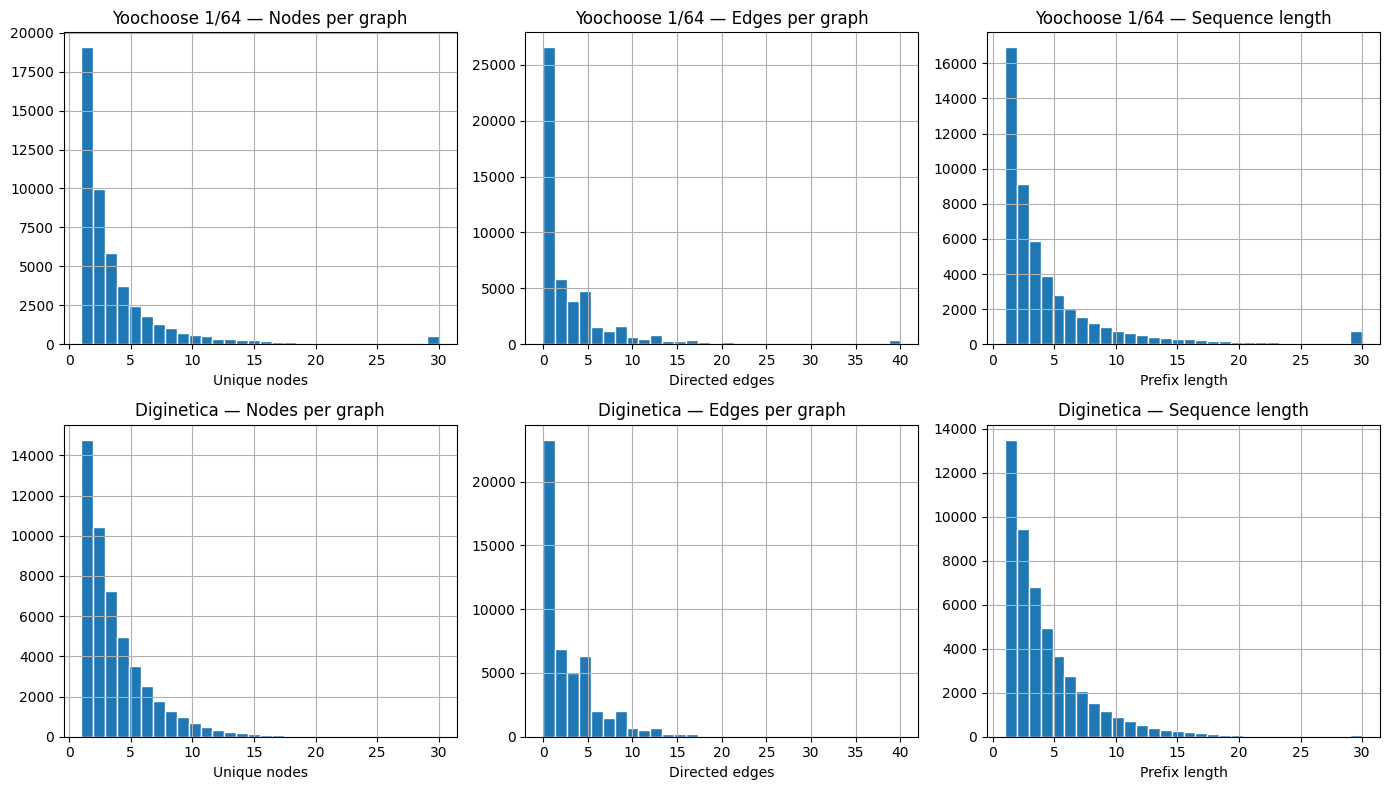

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row, (stats, name) in enumerate(
    [(yc_stats, "Yoochoose 1/64"), (dg_stats, "Diginetica")]
):
    stats["num_nodes"].clip(upper=30).hist(bins=30, ax=axes[row, 0], edgecolor="white")
    axes[row, 0].set_title(f"{name} — Nodes per graph")
    axes[row, 0].set_xlabel("Unique nodes")

    stats["num_edges"].clip(upper=40).hist(bins=30, ax=axes[row, 1], edgecolor="white")
    axes[row, 1].set_title(f"{name} — Edges per graph")
    axes[row, 1].set_xlabel("Directed edges")

    stats["seq_len"].clip(upper=30).hist(bins=30, ax=axes[row, 2], edgecolor="white")
    axes[row, 2].set_title(f"{name} — Sequence length")
    axes[row, 2].set_xlabel("Prefix length")

plt.tight_layout()
plt.show()

## Build and save full graph datasets

Materialize all prefix-target graphs and serialize to `data/processed/{name}_graphs.pkl.gz` for fast loading in training notebooks.

In [12]:
def build_all_graphs(sessions: list[Session]) -> list[Data]:
    """Materialize every prefix-target pair into a PyG Data object."""
    graphs: list[Data] = []
    for _, _, items in sessions:
        for end_idx in range(1, len(items)):
            graphs.append(build_session_graph(items[:end_idx], items[end_idx]))
    return graphs


def save_graph_dataset(
    graphs: list[Data], path: Path, dataset_name: str, split: str
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "dataset": dataset_name,
        "split": split,
        "num_graphs": len(graphs),
        "graphs": graphs,
    }
    with gzip.open(path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = path.stat().st_size / (1024 * 1024)
    print(f"Saved {len(graphs):,} graphs → {path}  ({size_mb:.1f} MB)")

In [13]:
%%time
print("Building Yoochoose 1/64 train graphs...")
yc_train_graphs = build_all_graphs(yc_train)
print(f"  {len(yc_train_graphs):,} graphs")

print("Building Yoochoose 1/64 test graphs...")
yc_test_graphs = build_all_graphs(yc_test)
print(f"  {len(yc_test_graphs):,} graphs")

Building Yoochoose 1/64 train graphs...
  392,738 graphs
Building Yoochoose 1/64 test graphs...
  1,723 graphs
CPU times: user 8.85 s, sys: 251 ms, total: 9.1 s
Wall time: 9.12 s


In [14]:
%%time
print("Building Diginetica train graphs...")
dg_train_graphs = build_all_graphs(dg_train)
print(f"  {len(dg_train_graphs):,} graphs")

print("Building Diginetica test graphs...")
dg_test_graphs = build_all_graphs(dg_test)
print(f"  {len(dg_test_graphs):,} graphs")

Building Diginetica train graphs...
  719,470 graphs
Building Diginetica test graphs...
  60,858 graphs
CPU times: user 16.6 s, sys: 451 ms, total: 17 s
Wall time: 17.1 s


In [ ]:
save_graph_dataset(
    yc_train_graphs,
    PROCESSED_DIR / "yoochoose_1_64_train_graphs.pkl.gz",
    "yoochoose_1_64",
    "train",
)
save_graph_dataset(
    yc_test_graphs,
    PROCESSED_DIR / "yoochoose_1_64_test_graphs.pkl.gz",
    "yoochoose_1_64",
    "test",
)
save_graph_dataset(
    dg_train_graphs,
    PROCESSED_DIR / "diginetica_train_graphs.pkl.gz",
    "diginetica",
    "train",
)
save_graph_dataset(
    dg_test_graphs,
    PROCESSED_DIR / "diginetica_test_graphs.pkl.gz",
    "diginetica",
    "test",
)

Saved 392,738 graphs → /Users/karol/university/semester/6/glebokie-i-grafowe-sieci-neuronowe/cwp/Session-based-Recommendation-with-Graph-Attention-Networks/data/processed/yoochoose_1_64_train_graphs.pkl.gz  (29.1 MB)
Saved 1,723 graphs → /Users/karol/university/semester/6/glebokie-i-grafowe-sieci-neuronowe/cwp/Session-based-Recommendation-with-Graph-Attention-Networks/data/processed/yoochoose_1_64_test_graphs.pkl.gz  (0.1 MB)
Saved 719,470 graphs → /Users/karol/university/semester/6/glebokie-i-grafowe-sieci-neuronowe/cwp/Session-based-Recommendation-with-Graph-Attention-Networks/data/processed/diginetica_train_graphs.pkl.gz  (52.5 MB)
Saved 60,858 graphs → /Users/karol/university/semester/6/glebokie-i-grafowe-sieci-neuronowe/cwp/Session-based-Recommendation-with-Graph-Attention-Networks/data/processed/diginetica_test_graphs.pkl.gz  (4.4 MB)
